# Bloomberg Risk-On / Risk-Off — Exploratory Data Analysis

First-pass EDA on the weekly Bloomberg dataset. The response variable `Y` flags **risk-off** weeks (`1`) vs **risk-on** weeks (`0`).

**Goals of this notebook**
1. Timeline of `Y` (when did risk-off regimes occur?).
2. Prevalence of risk-off by year.
3. Distribution of the most important features: **VIX**, **US 10Y (GT10)**, **DXY**, and **MSCI World return** — overall and split by regime.

> Note: `MXWO` (MSCI World) is listed in the metadata but is **not** present in the Markets sheet. We use `MXUS` (MSCI USA) weekly returns as the closest available proxy for the global-equity signal.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Make src/ importable when running from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_dataset, load_metadata, TARGET_COL

sns.set_theme(style='whitegrid', context='notebook')
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
RISK_ON, RISK_OFF = '#2c7fb8', '#d7301f'
pd.set_option('display.width', 120)

## 1. Load the cleaned dataset
The loader trims warm-up rows and prints a coverage report.

In [2]:
df = load_dataset()
meta = load_metadata()
df.head()

BLOOMBERG DATASET — COVERAGE REPORT
Raw series   :  1111 rows | 2000-01-11 -> 2021-04-20
Clean series :  1111 rows | 2000-01-11 -> 2021-04-20
Features      : 43 columns (incl. target 'Y')
Sampling      : ~7 days between observations (weekly)

Per-feature coverage (raw series):
          first_valid  last_valid  n_obs  n_missing  pct_missing
feature                                                         
BDIY       2000-01-11  2021-04-20   1111          0          0.0
CRY        2000-01-11  2021-04-20   1111          0          0.0
Cl1        2000-01-11  2021-04-20   1111          0          0.0
DXY        2000-01-11  2021-04-20   1111          0          0.0
ECSURPUS   2000-01-11  2021-04-20   1111          0          0.0
EMUSTRUU   2000-01-11  2021-04-20   1111          0          0.0
EONIA      2000-01-11  2021-04-20   1111          0          0.0
GBP        2000-01-11  2021-04-20   1111          0          0.0
GT10       2000-01-11  2021-04-20   1111          0          0.0
GTDEM10

,BDIY,CRY,Cl1,DXY,ECSURPUS,EMUSTRUU,EONIA,GBP,GT10,GTDEM10Y,...,MXJP,MXRU,MXUS,US0001M,USGG2YR,USGG30YR,USGG3M,VIX,XAUBGNL,Y
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-11,1388,157.26,25.77,100.56,0.077,230.5267,2.89,1.6460,6.657,5.541,...,990.59,224.33,1416.12,5.78125,6.428,6.671,5.426,22.50,283.25,0
2000-01-18,1405,165.01,28.85,101.86,0.043,231.3770,3.03,1.6383,6.748,5.644,...,993.98,234.37,1428.79,5.80250,6.465,6.747,5.378,21.50,287.65,0
2000-01-25,1368,167.24,28.28,102.41,0.135,232.3895,3.15,1.6496,6.692,5.515,...,974.83,216.82,1385.93,5.81875,6.432,6.634,5.562,23.02,287.15,0
2000-02-01,1311,166.85,28.22,104.92,0.191,231.9417,3.30,1.6106,6.619,5.459,...,1007.12,201.89,1385.31,5.88500,6.574,6.423,5.708,23.45,282.75,0
2000-02-08,1277,165.43,28.02,104.22,0.312,237.8117,3.26,1.6108,6.613,5.482,...,1034.58,218.00,1411.95,5.89125,6.678,6.231,5.677,21.25,298.40,1


In [3]:
# Human-readable labels for the features we focus on
meta_lookup = dict(zip(meta['variable'].str.replace(' ', ''), meta['description']))
print(f"Observations: {len(df)}  |  {df.index.min().date()} -> {df.index.max().date()}")
print(f"Risk-off prevalence overall: {df[TARGET_COL].mean():.1%}")
df[[TARGET_COL]].describe()

Observations: 1111  |  2000-01-11 -> 2021-04-20
Risk-off prevalence overall: 21.3%


,Y
count,1111.000000
mean,0.213321
std,0.409837
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


## 2. Timeline of the target `Y`
Risk-off weeks shaded in red over the VIX series for context. Clusters should line up with known stress episodes (2000-02 tech wobble, 2008 GFC, 2011 euro crisis, 2015-16, 2020 COVID).

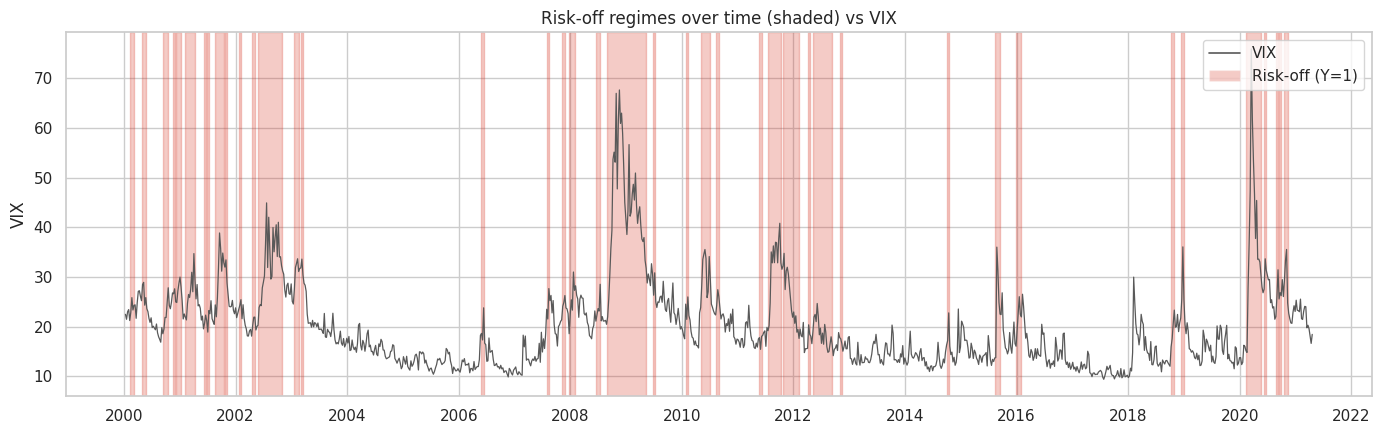

In [4]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(df.index, df['VIX'], color='0.35', lw=0.9, label='VIX')
ax.set_ylabel('VIX')

# Shade consecutive risk-off runs
y = df[TARGET_COL].values
idx = df.index
in_run = False
start = None
for i in range(len(y)):
    if y[i] == 1 and not in_run:
        in_run, start = True, idx[i]
    elif y[i] == 0 and in_run:
        ax.axvspan(start, idx[i], color=RISK_OFF, alpha=0.25)
        in_run = False
if in_run:
    ax.axvspan(start, idx[-1], color=RISK_OFF, alpha=0.25)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color='0.35', lw=1.2, label='VIX'),
           Patch(facecolor=RISK_OFF, alpha=0.25, label='Risk-off (Y=1)')]
ax.legend(handles=handles, loc='upper right')
ax.set_title('Risk-off regimes over time (shaded) vs VIX')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
fig.tight_layout()
fig.savefig(FIG_DIR / 'y_timeline.png', dpi=120)
plt.show()

## 3. Risk-off prevalence by year
Share of weeks each year flagged risk-off, with weekly counts.

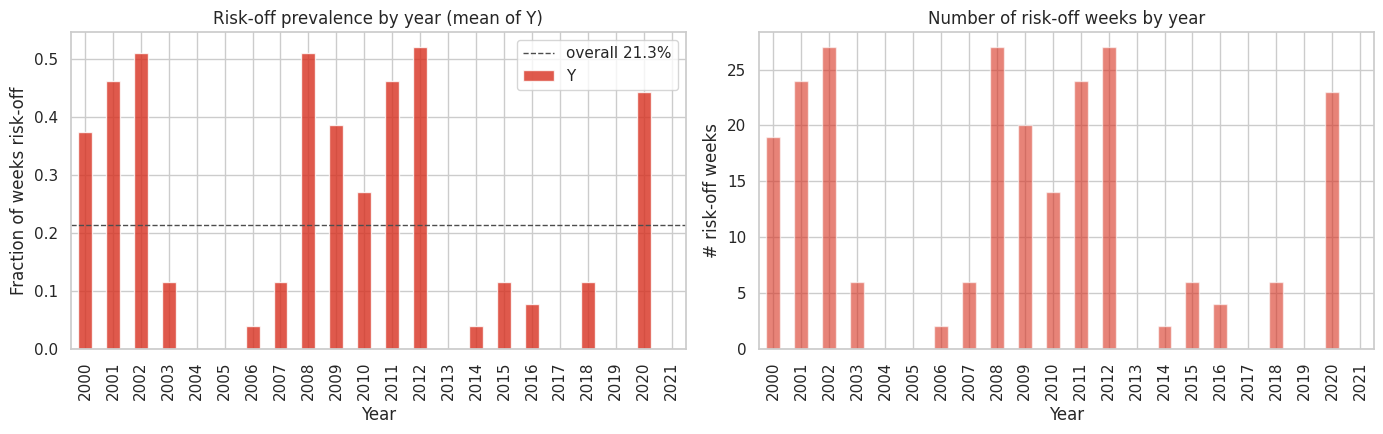

,n_weeks,risk_off_weeks,prevalence
Date,,,
2000,51,19,0.373
2001,52,24,0.462
2002,53,27,0.509
2003,52,6,0.115
2004,52,0,0.000
2005,52,0,0.000
2006,52,2,0.038
2007,52,6,0.115
2008,53,27,0.509


In [5]:
by_year = df[TARGET_COL].groupby(df.index.year)
prev = by_year.mean()
counts = by_year.sum().astype(int)
n_weeks = by_year.size()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
prev.plot(kind='bar', ax=ax1, color=RISK_OFF, alpha=0.8)
ax1.set_title('Risk-off prevalence by year (mean of Y)')
ax1.set_xlabel('Year'); ax1.set_ylabel('Fraction of weeks risk-off')
ax1.axhline(df[TARGET_COL].mean(), color='0.3', ls='--', lw=1,
            label=f'overall {df[TARGET_COL].mean():.1%}')
ax1.legend()

counts.plot(kind='bar', ax=ax2, color=RISK_OFF, alpha=0.6)
ax2.set_title('Number of risk-off weeks by year')
ax2.set_xlabel('Year'); ax2.set_ylabel('# risk-off weeks')
fig.tight_layout()
fig.savefig(FIG_DIR / 'y_prevalence_by_year.png', dpi=120)
plt.show()

pd.DataFrame({'n_weeks': n_weeks, 'risk_off_weeks': counts, 'prevalence': prev.round(3)})

## 4. Distribution of the most important features
We inspect **VIX**, **US 10Y yield (GT10)**, **DXY**, and a **MSCI World return proxy** (weekly % change of MXUS). Each is shown overall and split by regime to see how risk-off weeks differ.

In [6]:
# Build the focus feature set, including the MSCI World return proxy
feat = df[['VIX', 'GT10', 'DXY']].copy()
feat['MSCIWorld_ret'] = df['MXUS'].pct_change() * 100  # weekly % return, MSCI USA proxy
feat[TARGET_COL] = df[TARGET_COL]
feat = feat.dropna()

labels = {
    'VIX': 'VIX (Cboe Volatility Index)',
    'GT10': 'US 10Y yield (GT10, %)',
    'DXY': 'DXY (US Dollar Index)',
    'MSCIWorld_ret': 'MSCI World return proxy (MXUS, weekly %)',
}
feat.describe().round(2)

,VIX,GT10,DXY,MSCIWorld_ret,Y
count,1110.00,1110.00,1110.00,1110.00,1110.00
mean,19.99,3.26,90.93,0.12,0.21
std,8.65,1.33,11.38,2.39,0.41
min,9.43,0.51,71.33,-14.92,0.00
25%,13.64,2.19,81.24,-1.03,0.00
50%,17.97,3.11,89.71,0.34,0.00
75%,23.63,4.34,97.39,1.36,0.00
max,75.91,6.75,119.82,13.43,1.00


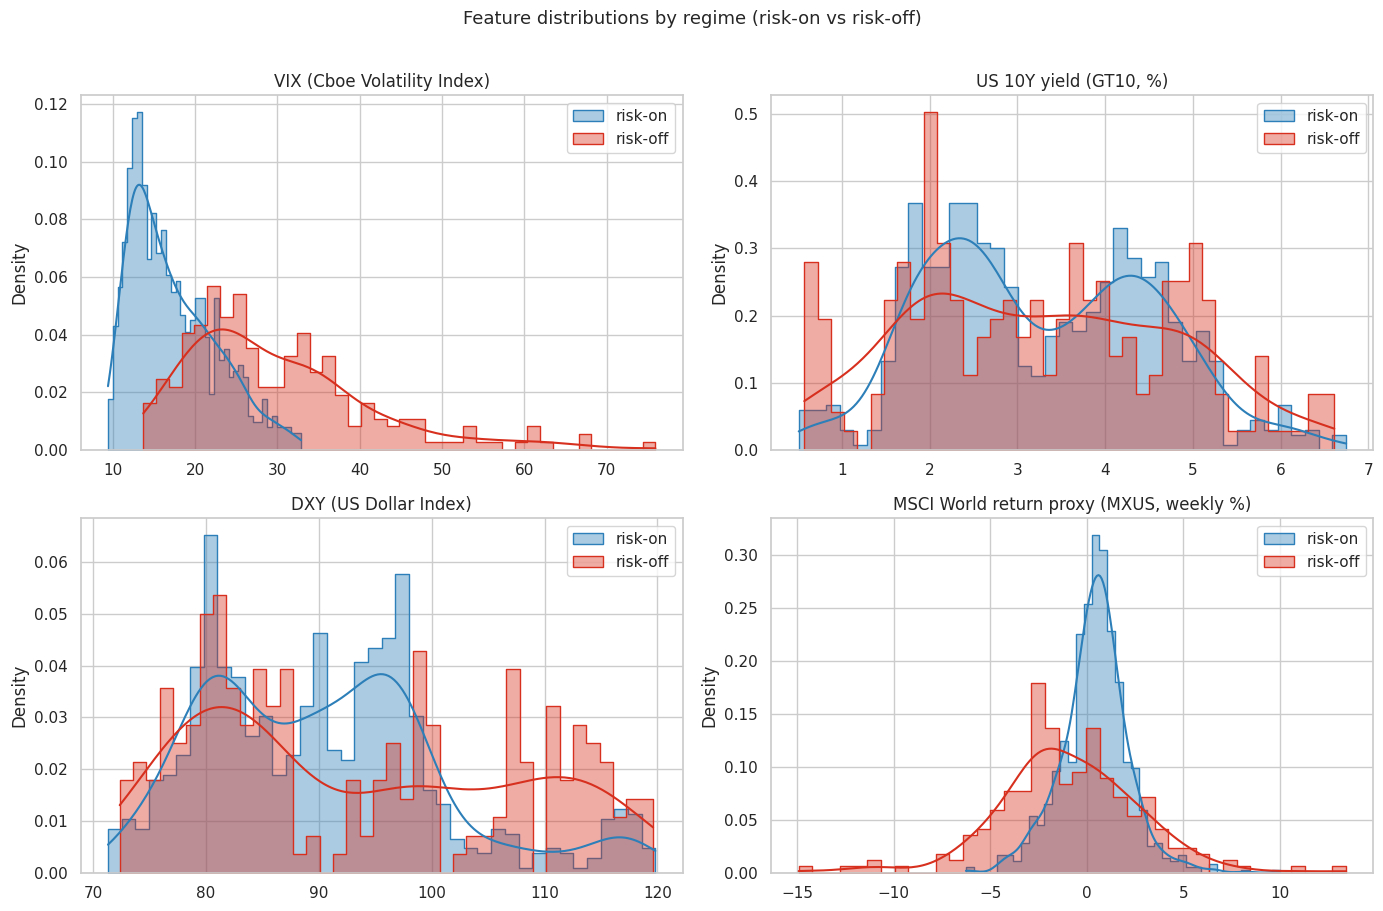

In [7]:
features = ['VIX', 'GT10', 'DXY', 'MSCIWorld_ret']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), features):
    for val, color, name in [(0, RISK_ON, 'risk-on'), (1, RISK_OFF, 'risk-off')]:
        sns.histplot(feat.loc[feat[TARGET_COL] == val, col], ax=ax, kde=True,
                     stat='density', color=color, alpha=0.4,
                     label=name, element='step', bins=40)
    ax.set_title(labels[col])
    ax.set_xlabel('')
    ax.legend()
fig.suptitle('Feature distributions by regime (risk-on vs risk-off)', y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / 'feature_distributions.png', dpi=120)
plt.show()

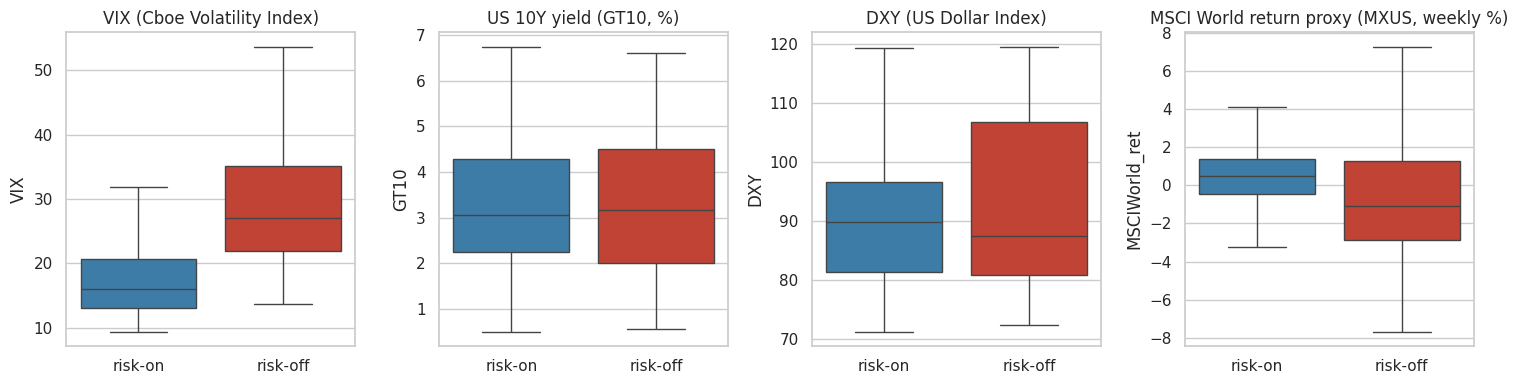

,VIX,GT10,DXY,MSCIWorld_ret
Y,,,,
0,17.29,3.27,90.31,0.41
1,29.92,3.25,93.19,-0.95


In [8]:
# Boxplots make the regime shift in level/spread easy to read
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
pal = {0: RISK_ON, 1: RISK_OFF}
for ax, col in zip(axes, features):
    sns.boxplot(data=feat, x=TARGET_COL, y=col, ax=ax, palette=pal, hue=TARGET_COL,
                legend=False, showfliers=False)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['risk-on', 'risk-off'])
    ax.set_title(labels[col]); ax.set_xlabel('')
fig.tight_layout()
fig.savefig(FIG_DIR / 'feature_boxplots.png', dpi=120)
plt.show()

# Mean by regime — quick numeric summary of the visual story
feat.groupby(TARGET_COL)[features].mean().round(2)

## 5. First takeaways
- **Risk-off weeks cluster** around known crises (2008 GFC, 2011 euro crisis, 2020 COVID), confirming the label is economically sensible.
- **VIX is markedly higher** during risk-off weeks — the strongest univariate separator.
- **MSCI World (proxy) returns are lower / more negative** in risk-off weeks, as expected.
- **DXY tends higher** in risk-off weeks (flight to the US dollar), while **US 10Y yields drift lower** (flight to safety), though both overlap more than VIX.
- The target is **imbalanced (~21% risk-off)** — keep this in mind for modelling (stratified splits, class weighting, PR-AUC over plain accuracy).